# Students Performance

In [27]:
from ucimlrepo import fetch_ucirepo 
from great_tables import GT
from plotnine import *
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

## Importando dados

In [3]:
# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 


### Features

In [4]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


### Targets

In [5]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


## Conhecendo o Dataset

In [6]:
description_table = student_performance.variables.loc[:,["name", "description"]]
description_table["description"] = description_table["description"].str.encode("ascii", "ignore").str.decode("ascii")
GT(description_table)

name,description
school,student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
sex,student's sex (binary: 'F' - female or 'M' - male)
age,student's age (numeric: from 15 to 22)
address,student's home address type (binary: 'U' - urban or 'R' - rural)
famsize,family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)
Pstatus,parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
Medu,"mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)"
Fedu,"father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 5th to 9th grade, 3 secondary education or 4 higher education)"
Mjob,"mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')"
Fjob,"father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')"


## Hipótese Inicial

As variáveis alvo serão as notas G1, G2 e G3. A variável G3 é a nota final do aluno, enquanto as variáveis G1 e G2 são as notas parciais do aluno. As notas são dadas em uma escala de 0 a 20, onde 0 é a pior nota e 20 é a melhor nota. Por se tratar de uma variável inteira o modelo de regressão linear não é o mais adequado para esse tipo de problema. O modelo de regressão de contagem é mais adequado para esse tipo de problema, pois ele é capaz de lidar com variáveis inteiras e também é capaz de lidar com variáveis que possuem uma distribuição assimétrica.

### Catboost

A vantagem das árvores de decisão é que elas são capazes de capturar relações não lineares entre as variáveis, lidar com dados categóricos sem a necessidade de codificação e são menos sensíveis a outliers. O CatBoost é uma implementação eficiente de árvores de decisão que utiliza técnicas de boosting para melhorar a performance do modelo. Aléme disso o modelo não fará extrapolações, ou seja, ele não fará previsões para valores de G3 que não estão presentes no conjunto de dados de treinamento. O modelo irá apenas fazer previsões para os valores de G3 que estão presentes no conjunto de dados de treinamento.


## Análise Exploratório de Dados

In [11]:
import scipy.stats as stats
from  statsmodels.graphics.gofplots import qqplot

### Preparando os dados

In [7]:
colunas = pd.DataFrame({'Coluna': X.columns.to_list(), 'Dtype': X.dtypes.astype(str).to_list()})
colunas


,Coluna,Dtype
0,school,str
1,sex,str
2,age,int64
3,address,str
4,famsize,str
5,Pstatus,str
6,Medu,int64
7,Fedu,int64
8,Mjob,str
9,Fjob,str


In [8]:
colunas_continuas = ['absences', 'age']

In [9]:

colunas_string = colunas.loc[colunas['Dtype'] == 'str',:]['Coluna'].to_list()
colunas_string


['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [10]:
colunas_int = colunas.loc[colunas['Dtype'] == 'int64',:]['Coluna'].to_list()
colunas_categoricas_ordinais = [item for item in colunas_int if item not in colunas_continuas] 
colunas_categoricas_ordinais

['Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health']

### Variáveis Target 

#### G1

##### Histograma

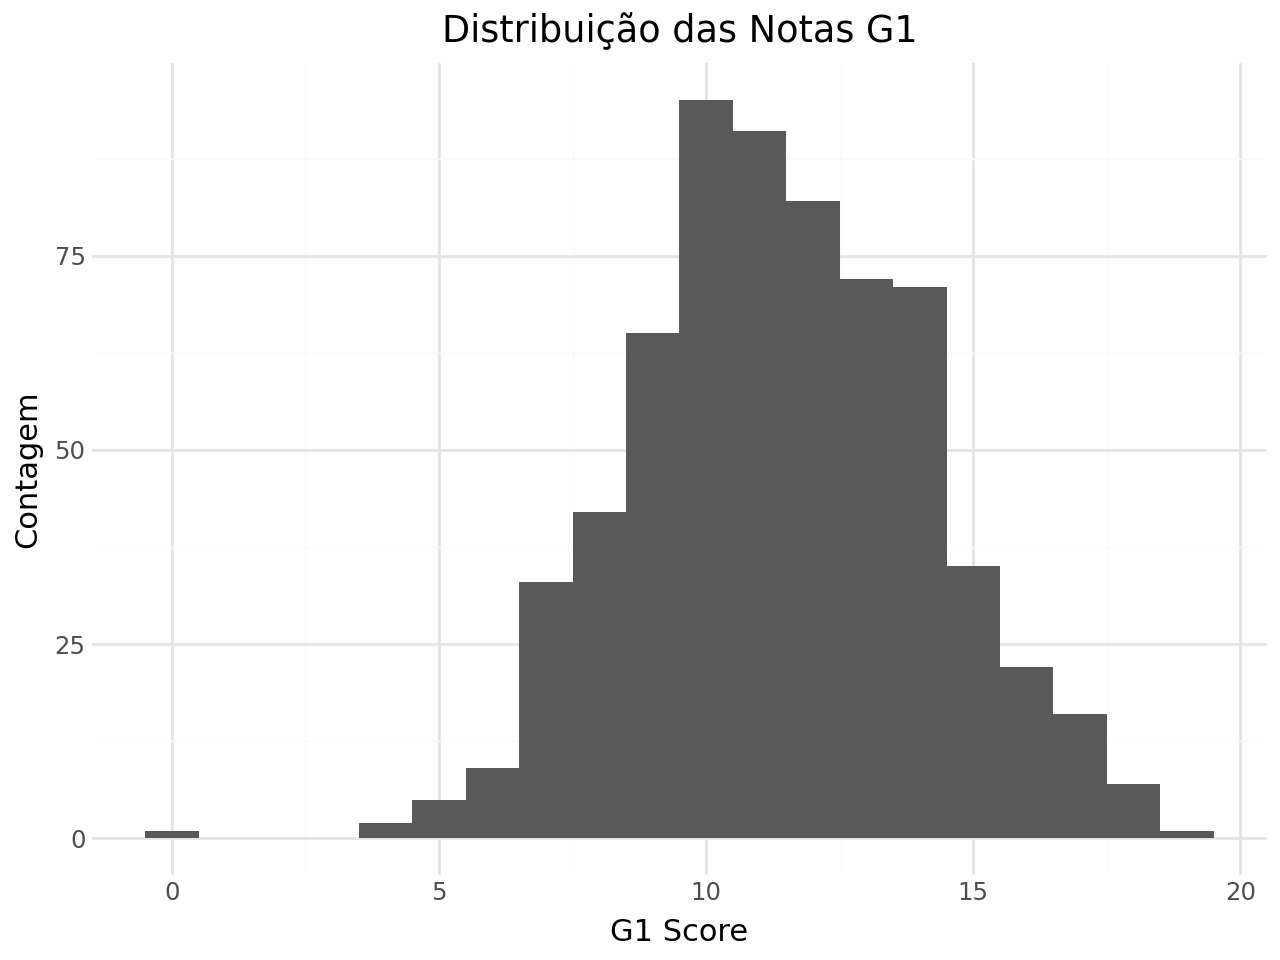

In [12]:
ggplot(y, aes(x="G1")) + geom_histogram(bins=20) + theme_minimal() + labs(title="Distribuição das Notas G1", x="G1 Score", y="Contagem")

##### Teste de Normalidade Shapiro-Wilk

In [13]:
g1_shapiro = stats.shapiro(y["G1"])

print(f"Shapiro-Wilk Teste para variável G1: Statistic={g1_shapiro.statistic:.4f}, p-value={g1_shapiro.pvalue:.4f}")

if(g1_shapiro.pvalue > 0.05):
    print("A variável G1 segue uma distribuição normal.")
else:
    print("A variável G1 não segue uma distribuição normal.")

Shapiro-Wilk Teste para variável G1: Statistic=0.9855, p-value=0.0000
A variável G1 não segue uma distribuição normal.


##### Teste de Nomalidade QQ Plot

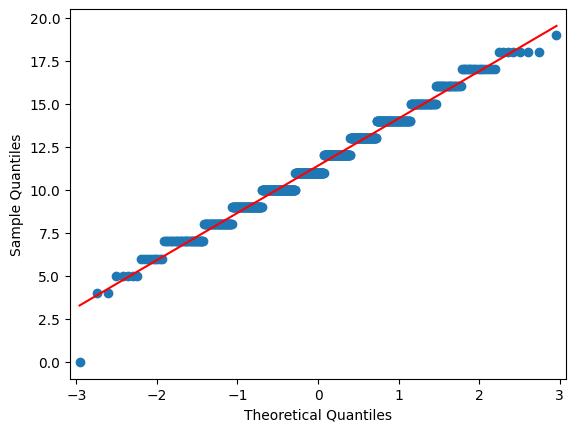

In [14]:
qqplot(y["G1"], line="s")


#### G2

##### Histograma

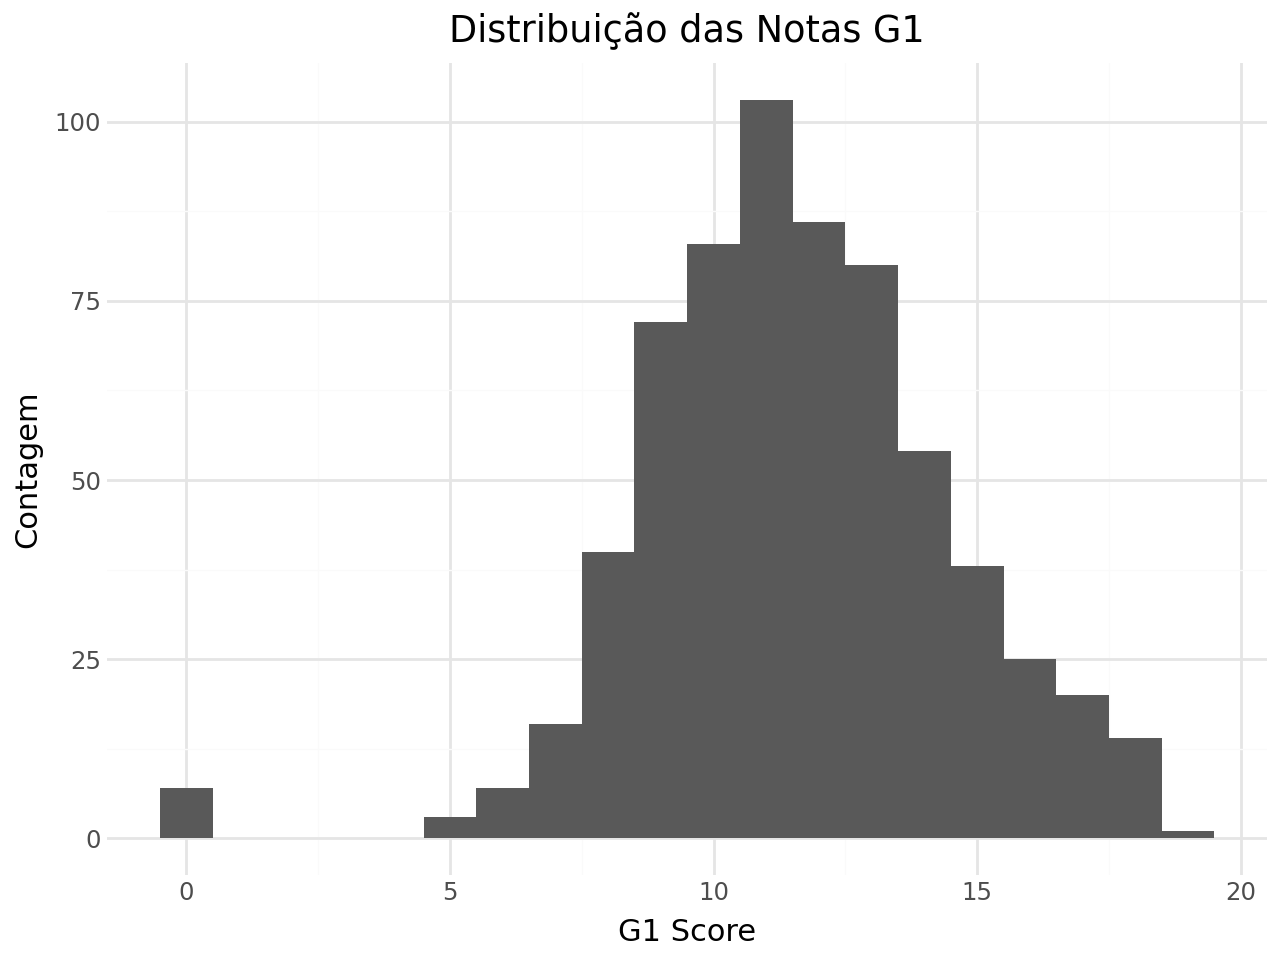

In [15]:
ggplot(y, aes(x="G2")) + geom_histogram(bins=20) + theme_minimal() + labs(title="Distribuição das Notas G1", x="G1 Score", y="Contagem")

##### Teste de Normalidade Shapiro-Wilk

In [16]:
g2_shapiro = stats.shapiro(y["G2"])

print(f"Shapiro-Wilk Teste para variável G2: Statistic={g2_shapiro.statistic:.4f}, p-value={g2_shapiro.pvalue:.4f}")

if(g2_shapiro.pvalue > 0.05):
    print("A variável G2 segue uma distribuição normal.")
else:
    print("A variável G2 não segue uma distribuição normal.")

Shapiro-Wilk Teste para variável G2: Statistic=0.9617, p-value=0.0000
A variável G2 não segue uma distribuição normal.


##### Teste de Normalidade QQ Plot

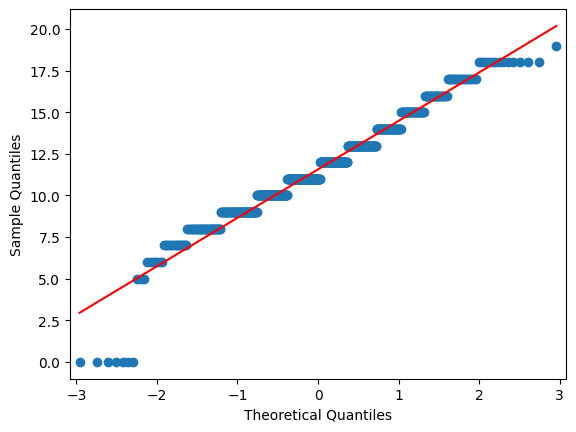

In [17]:
qqplot(y["G2"], line="s")

#### G3

##### Histograma

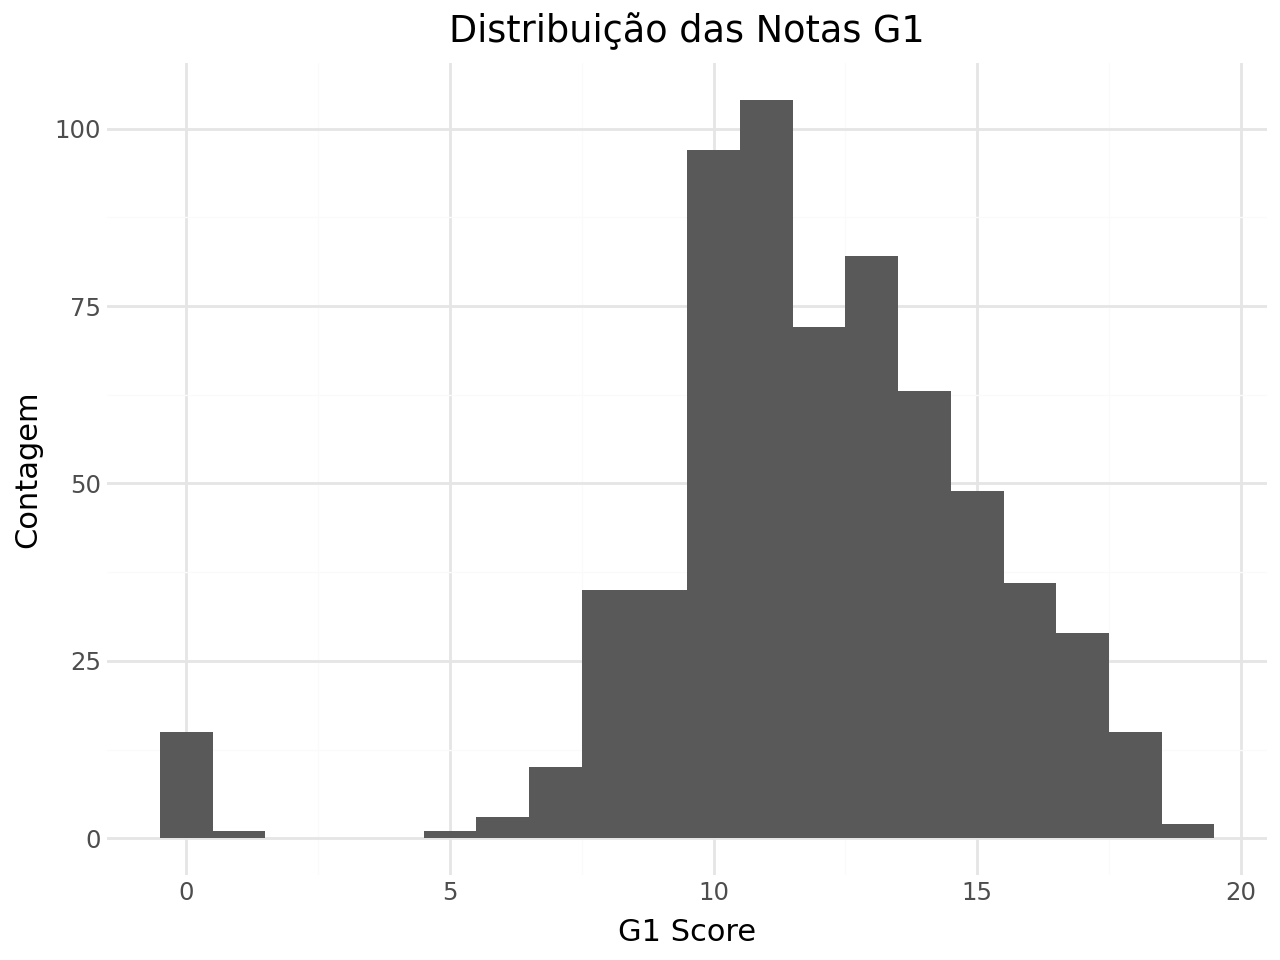

In [18]:
ggplot(y, aes(x="G3")) + geom_histogram(bins=20) + theme_minimal() + labs(title="Distribuição das Notas G1", x="G1 Score", y="Contagem")

##### Teste de Normalidade Shapiro-Wilk

In [19]:
g3_shapiro = stats.shapiro(y["G3"])

print(f"Shapiro-Wilk Teste para variável G3: Statistic={g3_shapiro.statistic:.4f}, p-value={g3_shapiro.pvalue:.4f}")

if(g3_shapiro.pvalue > 0.05):
    print("A variável G3 segue uma distribuição normal.")
else:
    print("A variável G3 não segue uma distribuição normal.")

Shapiro-Wilk Teste para variável G3: Statistic=0.9260, p-value=0.0000
A variável G3 não segue uma distribuição normal.


##### Teste de Normalidade QQ Plot

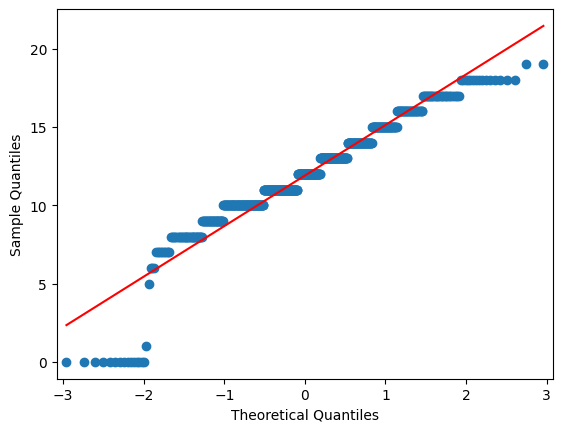

In [20]:
qqplot(y["G3"], line="s")

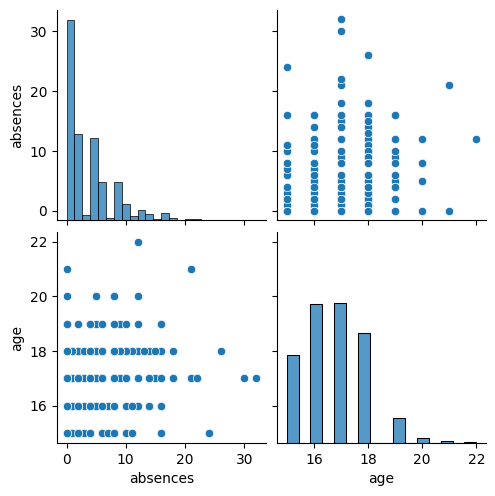

In [30]:
sns.pairplot(X[colunas_continuas])

In [ ]:
X[colunas_string]

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,no,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,no,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,no,no,yes,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,R,GT3,T,services,other,course,mother,no,no,no,yes,no,yes,yes,no
645,MS,F,U,LE3,T,teacher,services,course,mother,no,yes,no,no,yes,yes,yes,no
646,MS,F,U,GT3,T,other,other,course,mother,no,no,no,yes,yes,yes,no,no
647,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no


In [ ]:
X[colunas_continuas]

,absences,age
0,4,18
1,2,17
2,6,15
3,0,15
4,0,16
...,...,...
644,4,19
645,4,18
646,6,18
647,6,17
